### Define Constants for the Problem

In [ ]:
import numpy as np
from scipy.integrate import solve_ivp
from scipy.special import lambertw
from scipy.optimize import root_scalar

#=============================================================================================================================================================================
# define if you want to model for smooth land with "smooth" or rough land with "rough", this takes into account depressions in the ground
land = "rough"

# define if you want to model for a spill outside with "out" or a spill inside with "in"
place = "in"

# define T_s, the temperature of the liquid when discharged at the source (K)
T_s = 298

# define T_b, the boiling point of the liquid (K)
T_b = 373.15

# define rho, which is the liquid density (kg/m^3)
rho = 1000

# define v, the liquid kinematic viscosity (m^2/s)
v = 1.004*(10**-6)

# define L, the latent heat of vaporisatopm for the liquid (J/kg)
# note if this is a strong function of temperature, define in rhs with T_now for T (in K)
L = 2.26*(10**6)

# define c, the specific heat of the liquid (J/kg K)
# note if this is a strong function of temperature, define in rhs with T_now for T (in K)
c = 4186

# define Diff, mass diffusivity of the spilled liquid in air (m^2/s)
# note if this is a strong function of temperature, define in rhs with T_now for T (in K)
Diff = 0.242*(10**-4)

# define the surface tension for the liquid (N/m)
surf_tens = 0.0728

# define M, molecular weight of the liquid (kg/kmol)
M = 18.015

# define A_ant, B_ant and C_ant, coefficients A, B and C in the Antoine equation of the form log₁₀(P/bar) = A − B/(T + C) for the spilled liquid
A_ant = 5.40221
B_ant = 1838.675
C_ant = -31.737

# define the contact angle between the liquid and the surface (°) (if known), if unknown put -1
theta = -1

# define if the liquid is likely to be near-wetting the surface "y", moderately wetting "m" or strongly non-wetting "n"?
wetting = "y"

# define T_a, the ambient air temperature (K)
T_a = 303

# define rho_a, which is the density of air (kg/m^3) - here taken for air at 25 C
rho_a = 1.18

# define v_a, the kinematic viscosity of air (m^2/s) - here taken for air at 25 C
v_a = 1.55*(10**-5)

# define c_pa, the heat capacity of air (J/kg K) - here taken for air at 25 C
c_pa = 1005

# define k_a, the thermal conductivity of air (W/m K) - here taken for air at 25 C
k_a = 0.0257

# define mu_a, the dynamic viscosity of air (Pa s) - here taken for air at 25 C
mu_a = 1.86*(10**-5)

# define D, the drainage rate (m^3/s) (via drains or porous ground), if wanted
D = 0

# define a, the mean depth of depressions in the ground (m), equivalent to δϕ in paper 3.2 by Simmons et al. (2004)
a = 0.00

# define K_g, the thermal conductivity of the ground (W/m K) - here taken for concrete at 25 C
K_g = 3.10

# define alpha_g, the thermal diffusivity of the ground (m^2/s) - here taken for concrete at 25 C
alpha_g = 0.9*(10**-6)

# define heat flux to the pool via radiation (J/m^2 s), which should be constant
Q_r = 0

# specify whether you want to define U_10, the wind speed 10 m above the surface (m/s), with "wind" or give indoor space and air flow parameters with "indoors"
U_10_spec = "wind"

# define U_10, the wind speed 10 m above the surface (m/s) - outdoors this will depend on location (perhaps simulate 2-10 m/s) and indoors will be small (0.1-0.5 m/s)
# if you chose not define U_10 previously this can be left blank
U_10_user = 0.5

# if indoors and you did not define U_10, define the ventilation flowrate (m^3/s), the building height (m) and the building width (m) (which is perpendicular to the direction of airflow)
# also specifiy k_vent, which is a ventilation correction factor that is 0.5 if poorly ventilated, 1 if normally ventilated, and 2 if well ventilated
# if you chose to define U_10 previously these can be left blank
vent_flow = 20
height = 5
width = 10
k_vent = 1.0
#=============================================================================================================================================================================



#===============================================================
# the constants below can likely be kept as the are
#===============================================================

# T_A is a parameter for the Y definition (Y = ln(T_A/(T_b - T))), which is nearly always 1
T_A = 1.0

# A very small value to prevent division by zero or log(0) issues
epsilon_min_val = 1.0*(10**-12)

# g is the acceleration due to gravity (m/s^2)
g = 9.807

# C is the turbulent friction coefficient, which has an optimum value in the region of 1.5*10^-3
C = 1.5*(10**-3)

# R is the universal gas constant (J/kmol K)
R_gas_const = 8314

# Lamda is a constant used in numerically solving the temperature profile, and is best set to around 1000
Lamda = 1000

# Euler's constant (often represented as gamma)
Euler_const = 0.5772156649015328606065120900824024310421

# other constants used in equations
sigma = 0.85
kappa = 0.4


### Set up the ODEs (define S within this)

In [ ]:
# setting up the code to perform trials involved in each time step that will use updating global variables
from dataclasses import dataclass, field

@dataclass
class SpillHistory:
    times: list = field(default_factory=list)
    areas: list = field(default_factory=list)
    temps: list = field(default_factory=list)

    def append(self, t, A, T):
        self.times.append(float(t))
        self.areas.append(float(A))
        self.temps.append(float(T))

    def past_arrays(self, t, tol=1e-14):
        """
        Return accepted history strictly before current evaluation time t.
        """
        t_hist = np.asarray(self.times, dtype=float)
        A_hist = np.asarray(self.areas, dtype=float)
        T_hist = np.asarray(self.temps, dtype=float)

        mask = t_hist < (t - tol)
        return t_hist[mask], A_hist[mask], T_hist[mask]

def Q_c1_eqn(t_now, A_now, T_now, t_hist, A_hist, T_hist, Ta, K_ground, alpha_ground):
    t = np.asarray(t_hist, dtype=float)        # at each time
    t = np.append(t, t_now)
    A = np.asarray(A_hist, dtype=float)        # recording the spill area
    A = np.append(A, A_now)
    T = np.asarray(T_hist, dtype=float)        # and recording the spill temperature
    T = np.append(T, T_now)

    if t_now <= 0.0 or A_now <= 0.0:           # if time or area is <= 0 then return no flux
        return 0.0

    F = A * (T - Ta)                           # forms an array for the integral

    dt = np.diff(t)                            # creates an array one shorter than for time, is the difference between each step
    dFdt = np.diff(F) / dt                     # get an array of dF/dt for all times -  array is one shorter than before

    tau_mid = 0.5*(t[:-1] + t[1:])             # finds the time inbetween each time step
    kernel = 1.0/np.sqrt(t_now - tau_mid)
    integral = np.sum(dFdt*kernel*dt)          # through integration by parts and rearrangement of Q_c1, the integral can be represented as follows

    Q_c1 = -(K_ground/(A_now*np.sqrt(np.pi*alpha_ground)))*(F[0]/np.sqrt(t_now) + integral)    #full expression for Q_c1

    return Q_c1

def func_N(X):
    return np.real(lambertw(X))

def func_u_star_a(u_star_a, U_10):
    return u_star_a - ((kappa * U_10) / np.log((10 * g)/(0.015 * (u_star_a**2))))   # solving for u_star_a

def func_u_star_in(u_star, u_star_a, y, z_oa):
    return u_star - u_star_a*(y/(y + np.log((z_oa * u_star)/(0.13 * v_a))))         # solving for u_star when inside

def func_u_star_out(u_star, u_star_a, y, z_oa):
    return u_star - u_star_a*(y/(y + np.log((z_oa * g)/(0.015 * u_star**2))))       # solving for u_star when outside

if theta == -1:                                      # if the contact angle is not know, then estiamtions are made
  if wetting == "y":                                 # assumes a contact angle of around 40 degrees
    cos_var = 0.77
  elif wetting == "m":                               # assumes a contact angle of around 90 degrees
    cos_var = 0
  elif wetting == "n":                               # assumes a contact angle of around 140 degrees
    cos_var = -0.77
  else:
    raise ValueError("ERROR - define wetting as \"y\", \"m\" or \"n\"")
  H_0_1 = np.sqrt(2*surf_tens*(1 - cos_var)/(g*rho)) # equation for the minimum depth of spill
elif 0 <= theta <= 180:
  H_0_1 = np.sqrt(2*surf_tens*(1 - np.cos(np.deg2rad(theta)))/(g*rho))
else:
  raise ValueError("ERROR - define theta as a value between 0 and 180 degrees")

g_0 = 1
g_1 = 1 - Euler_const
g_2 = 1 + g_1**2 + ((np.pi**2)/6)
g_3 = g_1**3 + (3 + ((np.pi**2)/2))*(g_1) - (2*1.2020569)

min_T_for_antoine = -C_ant + epsilon_min_val         # minimum temperature for use in the Antoine equation before a negative denominator

def make_rhs(history):
    def rhs(t, y):
        R, U, V, Y, V_d, V_E = y

        T_now = T_b - T_A * np.exp(-Y)       # the temperature at this moment in time based on Y
        T_now = np.clip(T_now, min_T_for_antoine, T_b - epsilon_min_val)      # ensuring that current temperature will not cause the Antoine equation to fail

        #==============================================================================================================
        #==============================================================================================================
        # define S, which is the discharge rate of the spill (m^3/s), perhaps up to a certain time or as t changes
        # if S changes with t then use t_S_eqn in place of t

        t_S_eqn = t + epsilon_min_val

        if t < 60.0:
            S = 0.00025
        else:
            S = 0.00

        # define L, the latent heat of vaporisatopm for the liquid (J/kg), here if a strong function of temperature
        # define c, the specific heat of the liquid (J/kg K), here if a strong function of temperature
        # define any other global variables which are functions of temperature rather than constant here also
        #==============================================================================================================
        #==============================================================================================================

        R_safe = max(R, epsilon_min_val)     # safeguards so these values are not 0 which would cause a divide by 0 error
        V_safe = max(V, epsilon_min_val)
        a_safe = max(a, epsilon_min_val)

        A = np.pi * R_safe**2                # area of the spill
        H = V_safe / A                       # height of the spill

        if land == "smooth":                 # height based on if land has depressions or not
            H_e = H
            V_e = V_safe
        elif land == "rough":
            H_e = max((H - a), epsilon_min_val)
            V_e = max((V_safe - a * A), 0.0)
        else:
            raise ValueError("ERROR - define land as 'smooth' or 'rough'")

        t_hist, A_hist, T_hist = history.past_arrays(t) # accepted past history

        Q_c1 = Q_c1_eqn(           # Q_c1 term determined using past and trial states
            t_now=t,
            A_now=A,
            T_now=T_now,
            t_hist=t_hist,
            A_hist=A_hist,
            T_hist=T_hist,
            Ta=T_a,
            K_ground=K_g,
            alpha_ground=alpha_g
        )

        t_H = A / (4 * np.pi * alpha_g)
        Q_apos = -(2 / np.pi) * ((alpha_g * t_H) ** (-1/2)) * K_g * (T_now - T_a)  # another equation on the conduction effects
        Q_c = np.cbrt(Q_c1**3 + Q_apos**3)                                         # improving accuracy of the conduction effects by combining equations

        epsilon = max((8 * U**2) / (g * a_safe), epsilon_min_val)                  # constants foruse in correlations
        phi_1 = np.sqrt(1 + epsilon) - 1

        H_0_2 = ((6*v*S)/(np.pi*g))**(1/4)          # different equation for the minimum depth of spill

        H_0 = max(H_0_1, H_0_2)                     # takes greater of two equations for the minimum spill depth

        if land == "smooth":                        # defining the shape factors for the depth profile of the pool
            s = H_0 / H
            phi_2 = 1.0
        elif land == "rough":
            s = (phi_1 * a_safe) / (2 * H)
            phi_2 = 1 - (2 / epsilon) * phi_1
        else:
            raise ValueError("ERROR - define land as \"smooth\" or \"rough\"")

        F_L = 2.53 * ((3 * v * U) / (H_e**2))       # resistance to laminar flow
        F_T = (4.49 * C * U * abs(U)) / H_e         # resistance to turbulent flow
        F = np.sign(U) * max(abs(F_L), abs(F_T))    # larger of two resistances

        Sc = v_a / Diff # defining the Schmidt number

        if U_10_spec == "wind":
            U_10 = U_10_user
        elif U_10_spec == "indoors":
            U_10 = (vent_flow * k_vent) / (height * width)
        else:
            raise ValueError("ERROR - define U_10_SPEC as \"wind\" or \"indoors\"")

        # the following determines constants used to for the vaporisation flux
        if place == "out":
            sol_u_star_a = root_scalar(func_u_star_a, args=(U_10,), bracket=[-10, 50000], method='brentq')
            u_star_a = sol_u_star_a.root
            z_oa = (0.015 * (u_star_a**2))/g
        elif place == "in":
            u_star_a = kappa * U_10 / func_N(kappa * U_10 * 10 / (0.13 * v_a))
            z_oa = 0.13 * v_a / (u_star_a)

        else:
            raise ValueError("ERROR - define place as \"out\" or \"in\"")

        z = func_N((kappa**2 * (A**0.5))/z_oa)

        if place == "out":
            sol_u_star = root_scalar(func_u_star_out, args=(u_star_a, z, z_oa,), bracket=[-10, 50000], method='brentq')
            u_star = sol_u_star.root
            z_o = (0.015 * (u_star**2))/g
        elif place == "in":
            u_star = u_star_a
            z_o = (0.13 * v_a)/u_star
        else:
            raise ValueError("ERROR - define place as \"out\" or \"in\"")

        n = 1 / func_N(((A**0.5)/z_o)*((kappa**2)/sigma)*np.exp(-(1 + Euler_const)))

        gamma = 1 - s

        # this may use v_a, but either way this makes little difference to the result
        Re_o = (u_star * z_o) / v

        if place == "out":
            beta = (7.3 * (Re_o**0.25) * (Sc**0.5)) - (5 * sigma)
        elif place == "in":
            beta = ((3.85 * (Sc**(1/3)) - 1.3)**2) + (sigma / kappa) * np.log(0.13 * Sc)
        else:
            raise ValueError("ERROR - define place as \"out\" or \"in\"")

        lamda = (n**-1) + 2 + np.log(2 * (1 + n)**2) - Euler_const + (kappa / sigma) * (1 + n) * beta

        G = (
            0.5
            - (g_0 / np.pi) * np.arctan(lamda / np.pi)
            + g_1 / (lamda**2 + np.pi**2)
            + g_2 * lamda / ((lamda**2 + np.pi**2)**2)
            + g_3 * (lamda**2 - ((np.pi**2) / 3)) / ((lamda**2 + np.pi**2)**3)
        )

        p_V = (10**(A_ant - (B_ant / (T_now + C_ant)))) * (10**5)
        x_val = p_V / 101325
        x = np.clip(x_val, epsilon_min_val, 1.0 - epsilon_min_val)

        W = (M * p_V / (R_gas_const * T_now)) * (u_star / rho) * (kappa / sigma) * (1 + n) * G * (x**-1) * np.log((1 - x)**-1)

        Pr_a = mu_a * c_pa / k_a # defining the Prandtl number for air

        # the following determines constants used for heat convected from air
        if place == "out":
            beta_dash = (7.3 * (Re_o**0.25) * (Pr_a**0.5)) - (5 * sigma)
        elif place == "in":
            beta_dash = ((3.85 * (Pr_a**(1/3)) - 1.3)**2) + (sigma / kappa) * np.log(0.13 * Pr_a)
        else:
            raise ValueError("ERROR - define place as \"out\" or \"in\"")

        lamda_dash = (n**-1) + 2 + np.log(2 * (1 + n)**2) - Euler_const + (kappa / sigma) * (1 + n) * beta_dash

        G_dash = (
            0.5
            - (g_0 / np.pi) * np.arctan(lamda_dash / np.pi)
            + g_1 / (lamda_dash**2 + np.pi**2)
            + g_2 * lamda_dash / ((lamda_dash**2 + np.pi**2)**2)
            + g_3 * (lamda_dash**2 - ((np.pi**2) / 3)) / ((lamda_dash**2 + np.pi**2)**3)
        )

        Q_a = (rho_a * c_pa * u_star) * (T_a - T_now) * (kappa / sigma) * (1 + n) * G_dash * (x**-1) * np.log((1 - x)**-1)

        Q = Q_c + Q_a + Q_r # total heat flux

        dR = U * phi_2
        dU = (gamma * (4 * g * H_e) / R_safe) - F
        dV = S - (W * A) - D
        # equation for dY altered to include rho compared to origonal GASP writing as seems to be a mistake
        dY = (Lamda * np.exp(Y) * (Lamda**2 + np.exp(2 * Y))**(-1/2)) * (1 / T_A) * ((A / (rho * c * V_safe)) * (Q - rho * W * L) + (S / V_safe) * (T_s - T_now))
        dV_d = S
        dV_E = W * A

        return [dR, dU, dV, dY, dV_d, dV_E]

    return rhs

### Solve ODEs (Define Initial Conditions)

In [ ]:
import matplotlib.pyplot as plt

#=========================================================================================================
# define the initial spill radius (m), which is 0 if there is no initial spill
initial_R_user = 0.00

# define the initial spill volume (m^3), which is 0 if there is no initial spill
initial_V_user = 0.00

# define initial spill temperature (K), if spill has no initial volume then set to T_s
initial_temp = T_s

# define how long you want the simulation to run for (s)
t_end = 120.0

# define time step size when solving (s), which will depend parlty on t_end and also the detail required
# a setting of 0.1 s seemed reasonable
dt_solve_ivp = 0.1
#=========================================================================================================



# ensures initial temperature is not above boiling point
if (T_b - initial_temp) <= 0:
    raise ValueError("Error - initial temperature must be less than T_b (boiling point)")

# Y = ln(T_A/(T_b - T)), so
initial_Y = np.log(T_A / (T_b - initial_temp))

t_start = 0.0

initial_R_safe = max(initial_R_user, epsilon_min_val)  # ensuring divide by 0 errors do not occur
initial_V_safe = max(initial_V_user, epsilon_min_val)

initial_state = [
    initial_R_safe,    # R (radius)
    0.0,               # U (spreading velocity, starting at 0)
    initial_V_safe,    # V (spill volume)
    initial_Y,         # Y (temperature-related variable)
    0.0,               # V_d (volume discharged, starting at 0)
    0.0                # V_E (volume evaporated, starting at 0)
]

history = SpillHistory()

current_y = np.array(initial_state, dtype=float)     # sets the initial parameters as the current variables
current_t = t_start                                  # sets the initial start time

# determine initial variables and store them
A0 = np.pi * max(initial_state[0], epsilon_min_val)**2
T0 = T_b - T_A * np.exp(-initial_state[3])
history.append(current_t, A0, T0)

# create data lists for plots
times = [current_t]
y_values = [current_y.copy()]
radii = [initial_state[0]]
velocities = [initial_state[1]]
areas = [A0]
temps = [T0]
volume_discharged = [initial_state[4]]
volume_in_spill = [initial_state[2]]
volume_evaporated = [initial_state[5]]

rhs = make_rhs(history)

while current_t < t_end: # for the time specified
    t_span_end = min(current_t + dt_solve_ivp, t_end) # the next time step is either another step along or the end, whichever is first

    # solve the set of ODEs using the BFD method
    sol = solve_ivp(
        rhs,
        [current_t, t_span_end],
        current_y,
        method='BDF',
        t_eval=[t_span_end],
        rtol=1e-6,
        atol=1e-8
    )

    if sol.status < 0 or len(sol.t) == 0:
        print(f"Integration failed at t = {current_t}")
        break

    # update variables
    new_t = sol.t[-1]
    new_y = sol.y[:, -1]

    R_new, U_new, V_new, Y_new, V_d_new, V_E_new = new_y
    A_new = np.pi * max(R_new, epsilon_min_val)**2
    T_new = T_b - T_A * np.exp(-Y_new)
    T_new = np.clip(T_new, min_T_for_antoine, T_b - epsilon_min_val)

    if V_new <= 0:
      print("Simulation stopped as spill has completely evaporated")
      break

    # append only accepted endpoint to permanent history
    history.append(new_t, A_new, T_new)

    # storing values for plotting/post-processing
    times.append(new_t)
    y_values.append(new_y.copy())
    radii.append(R_new)
    velocities.append(U_new)
    areas.append(A_new)
    temps.append(T_new)
    volume_discharged.append(V_d_new)
    volume_in_spill.append(V_new)
    volume_evaporated.append(V_E_new)

    # update times and variables
    current_t = new_t
    current_y = new_y

    if current_t >= t_end: # if ever time exceeds what it is supposed to go up to loop ends
        break

mass_evap = np.array(volume_evaporated)*rho # determining the mass of liquid evaorated
spill_height = np.array(volume_in_spill)/np.array(areas)
print("Simulation completed.")

Simulation completed.


### Visualization of Results

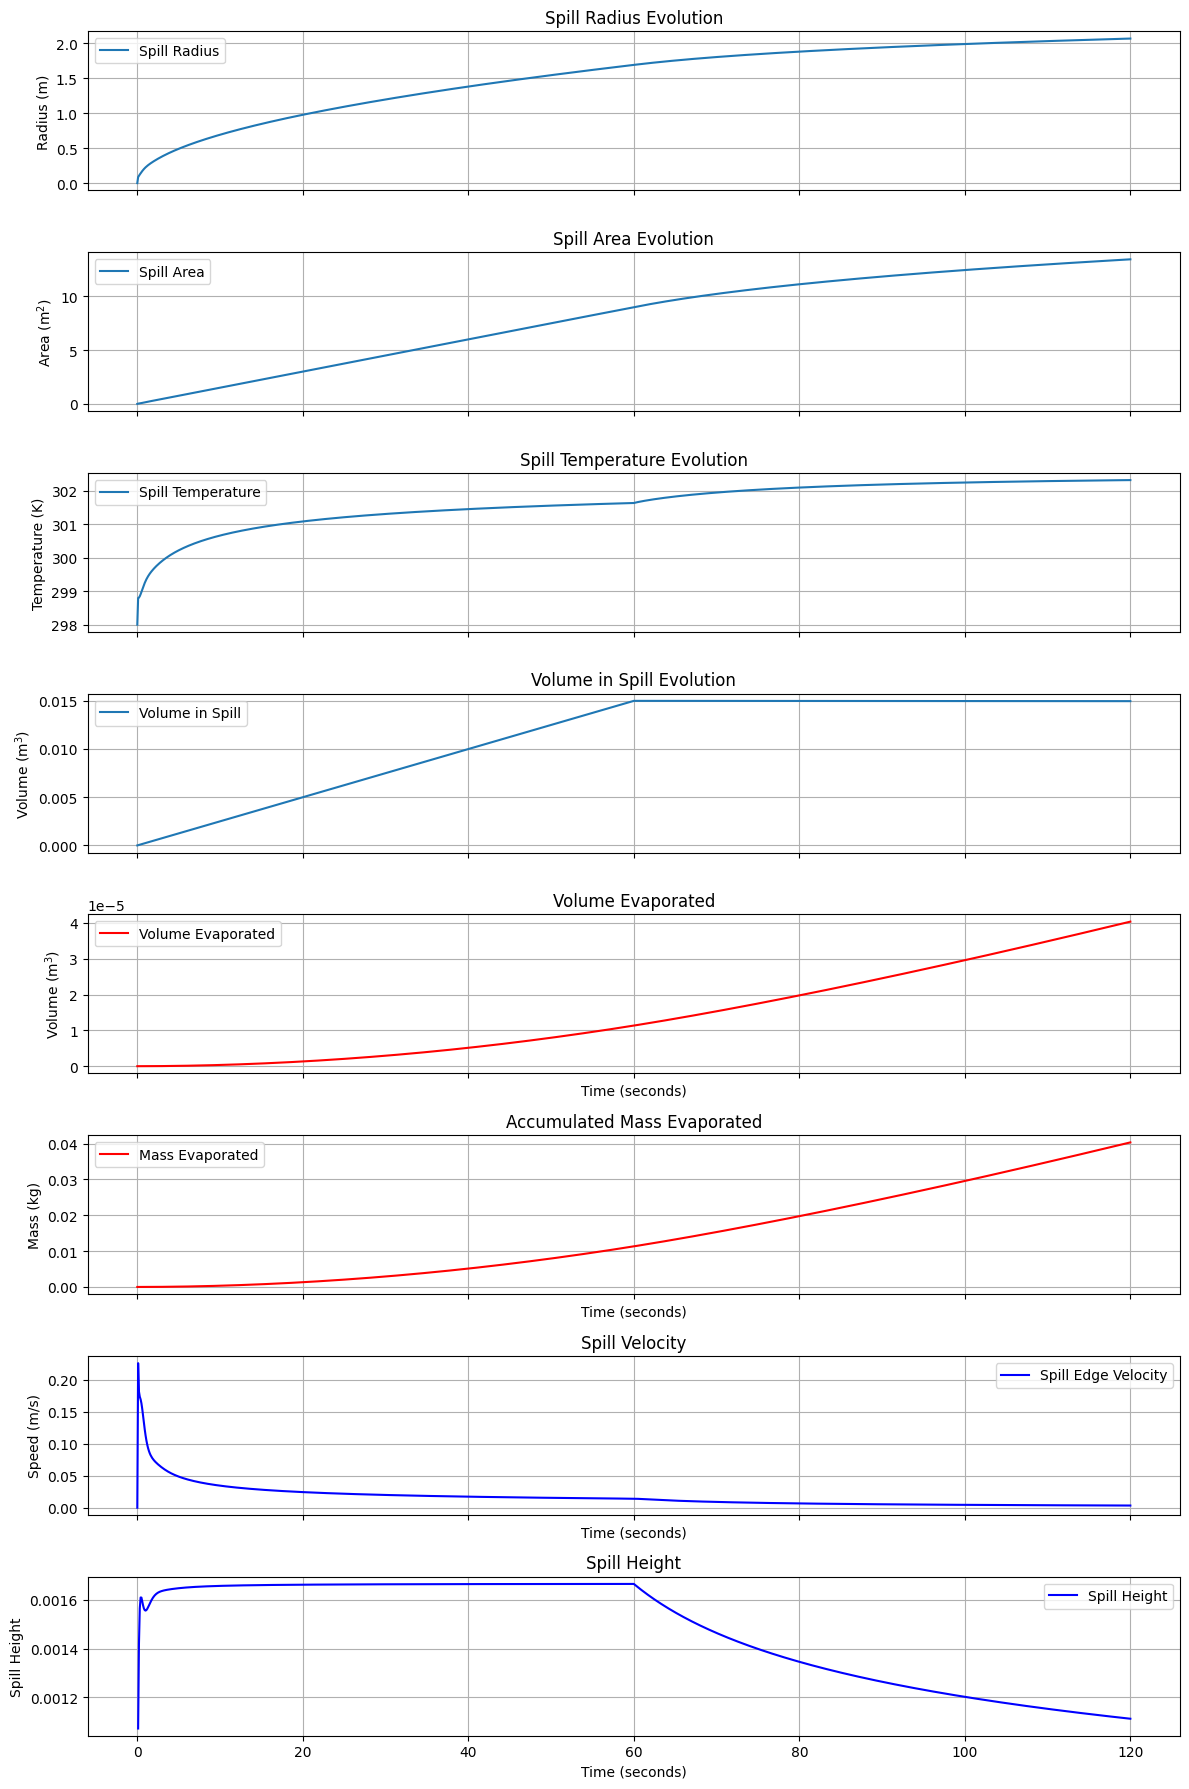

In [ ]:
fig, axes = plt.subplots(8, 1, figsize=(12, 18), sharex=True)

# Plot 1: Spill Raduius over Time
axes[0].plot(times, radii, label='Spill Radius')
axes[0].set_ylabel('Radius (m)')
axes[0].set_title('Spill Radius Evolution')
axes[0].grid(True)
axes[0].legend()

# Plot 2: Spill Area over Time
axes[1].plot(times, areas, label='Spill Area')
axes[1].set_ylabel('Area (m$^2$)')
axes[1].set_title('Spill Area Evolution')
axes[1].grid(True)
axes[1].legend()

# Plot 3: Spill Temperature over Time
axes[2].plot(times, temps, label='Spill Temperature')
axes[2].set_ylabel('Temperature (K)')
axes[2].set_title('Spill Temperature Evolution')
axes[2].grid(True)
axes[2].legend()

# Plot 4: Volume in Spill over Time
axes[3].plot(times, volume_in_spill, label='Volume in Spill')
axes[3].set_ylabel('Volume (m$^3$)')
axes[3].set_title('Volume in Spill Evolution')
axes[3].grid(True)
axes[3].legend()

# Plot 5: Volume Evaporated over Time
axes[4].plot(times, volume_evaporated, label='Volume Evaporated', color='red')
axes[4].set_xlabel('Time (seconds)')
axes[4].set_ylabel('Volume (m$^3$)')
axes[4].set_title('Volume Evaporated')
axes[4].grid(True)
axes[4].legend()

#Plot 6: Mass Evaporated over Time
axes[5].plot(times, mass_evap, label='Mass Evaporated', color='red')
axes[5].set_xlabel('Time (seconds)')
axes[5].set_ylabel('Mass (kg)')
axes[5].set_title('Accumulated Mass Evaporated')
axes[5].grid(True)
axes[5].legend()

#Plot 7: Velocity at Pool Edge over Time
axes[6].plot(times, velocities, label='Spill Edge Velocity', color='blue')
axes[6].set_xlabel('Time (seconds)')
axes[6].set_ylabel('Speed (m/s)')
axes[6].set_title('Spill Velocity')
axes[6].grid(True)
axes[6].legend()

#Plot 8: Avargae Spill Height over Time
axes[7].plot(times[1:], spill_height[1:], label='Spill Height', color='blue')
axes[7].set_xlabel('Time (seconds)')
axes[7].set_ylabel('Spill Height')
axes[7].set_title('Spill Height')
axes[7].grid(True)
axes[7].legend()

plt.tight_layout()
plt.show()

# If wanted, could get a rough concentration distribution of the evaporated liquid above the spill
# Look for a given time increment, which of a certain radius was exceeded
# Then within each time increment, attribute the radii which were exceeded
# Determine the volume (and therefore mass), evaporated in each time step and this can be divided over covered radii
# Once all time increments have been completed and summed, this will give a a concentration distribution above a series of annuli
# Then depending on the height above pool (roof) can get an intial conc profile (no radial dispersion though)